# Homework 7

## Your Name Here (or your names here if you are pair programming)

Student Name: Leia Nayana Das

Student UT EID: lnd749

---

Partner Name: Javier Diaz de Sandi Viramontes

Partner UT EID: jd52288

---

Date Created: 10/21/25

Date Last Modified: 10/22/25

---

Totoal Points 20. 



## Supprt Vector Machine 

In [122]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [123]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task - 1 Implement SVM using libraries (4 points)
We want to use **Suppert Vector Machine** to perdict if the patients will have heart problems or not. The column "Target" in our datasets includes data about heart diseases. If the patient had heart disease we have a 1 and if not a zero. 

Prepare your data set for predicting heart disease ("Target" column) out of 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 


Split your data into 80% traning data and 20% test data, and implement Support Vector Machine using Scikit-Learn. 





In [129]:
# set up data set and split training and testing
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

X = heart_df[["Age", "Sex", "Chol"]]
# scale X
scaler = StandardScaler()
X = scaler.fit_transform(X)
# reclassify target so that 1 is yes and 0 is no
targetClass = {"Yes": 1, "No": 0}
heart_df = heart_df.replace({"Target": targetClass})
y = heart_df["Target"]
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=38)

# using SVC
model = svm.LinearSVC(C=0.01, max_iter=100, fit_intercept=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



# Task 2 - (4 points)

Cacluate the accuracy, Precision, Recall and F1 score of your **SVM** implementaion from Task 1. 
Print the results. 

You may use library methods for this task if you choose to.


In [130]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.66      0.71        32
           1       0.68      0.79      0.73        29

    accuracy                           0.72        61
   macro avg       0.73      0.72      0.72        61
weighted avg       0.73      0.72      0.72        61



# Task 3 - Implement SVM without using libraries  - (4 points)

Implement SVM from scratch using Hinge Loss function and Gradient Descent. 
Try to produce the same result as you get from the libraries. 


* Do as many iterations as needed 
* Do maximum **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher. 
* Visualize your costs. 
* No need to add an y-intercept in this task. 
* You can use libraries to report accuracy, Precision, Recall and F1. 



              precision    recall  f1-score   support

           0       0.78      0.66      0.71        32
           1       0.68      0.79      0.73        29

    accuracy                           0.72        61
   macro avg       0.73      0.72      0.72        61
weighted avg       0.73      0.72      0.72        61

              precision    recall  f1-score   support

           0       0.77      0.62      0.69        32
           1       0.66      0.79      0.72        29

    accuracy                           0.70        61
   macro avg       0.71      0.71      0.70        61
weighted avg       0.72      0.70      0.70        61



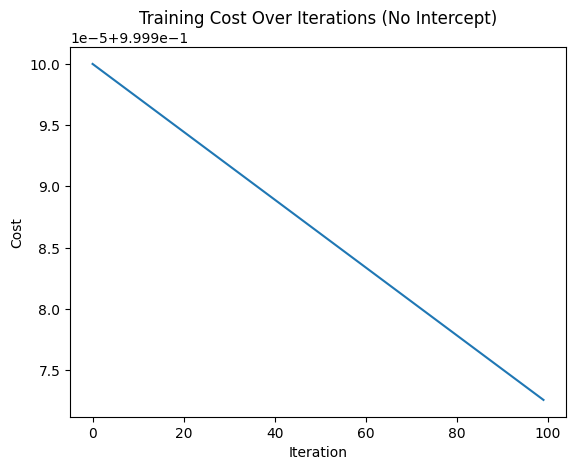

In [ ]:
modified from in-class example

def computeHingeLoss(X, y, W, regularization_factor):
    n = X.shape[0]
    distances = 1 - y * (np.dot(X, W))
    
    # max(0, distances)
    distances[distances < 0] = 0 
    
    hinge_loss = (np.sum(distances) / n)
    lambd = 1/(regularization_factor)
    return (lambd / 2 * np.dot(W, W) + hinge_loss)

def calculateGradient(X, y, W, regularization_factor):
    if type(y) == np.float64:
        y = np.array([y])
        X = np.array([X])
        
    distance = 1 - (y * np.dot(X, W))
    
    dw = np.zeros(len(W))
    
    for ind, d in enumerate(distance):
        
        if (d < 0):
            di = W
        else:
            di = W - (regularization_factor * y[ind] * X[ind])
            
        dw += di
    
    dw = dw/len(y)  
    
    return dw

# def computeHingeLoss(X, y, W, regularization_factor):
#     n = X.shape[0]
#     distances = 1 - y * (np.dot(X, W))
#     distances[distances < 0] = 0  # hinge = max(0, margin)

#     # hinge term: mean over samples; L2 term weighted by regularization_factor
#     hinge_loss = np.mean(distances)
#     return (0.5 * regularization_factor * np.dot(W, W) + hinge_loss)

# def calculateGradient(X, y, W, regularization_factor):
#     # keep your scalar guard (unchanged)
#     if type(y) == np.float64:
#         y = np.array([y])
#         X = np.array([X])

#     distance = 1 - (y * np.dot(X, W))

#     # L2 gradient once per batch
#     dw = regularization_factor * W

#     # add hinge gradient contributions only for active samples
#     for ind, d in enumerate(distance):
#         if d > 0:  # active margin
#             dw += -(y[ind] * X[ind])

#     # average over samples (since hinge was a mean)
#     dw = dw / len(y)
#     return dw


# run SVM
weights = np.zeros(3)
numIter = 100
learningRate = 0.00001
regularization = 0.01
costList = []
for i in range(0, numIter):
    cost = computeHingeLoss(X_train, y_train, weights, regularization)
    # print("Epoch", i, "Cost is:", cost, "weights", weights)
    costList.append(cost)
    grad = calculateGradient(X_train, y_train, weights, regularization)
    weights = weights - learningRate * grad

# calculating prediction
y_predMan = np.zeros(len(y_test))
for i in range(len(y_test)):
    y_predElement = X_test[i][0]*weights[0] + X_test[i][1]*weights[1] + X_test[i][2]*weights[2]
    if y_predElement > 0:
        y_predElement = 1
    else:
        y_predElement = 0
    y_predMan[i] = y_predElement


print(classification_report(y_test,y_pred))
print(classification_report(y_test,y_predMan))

# Plot cost over iterations
plt.plot(np.arange(len(costList)), costList)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost Over Iterations (No Intercept)')
plt.show()



# Task 4 - Compare SVM results with Logistic Regression - (4 points)

Which model performs better here? Compare your results wit the logistic regression. You can use libraries for this task, it is not necessary to implement logistic regression from sratch.


In [5]:
# Add your code Here! 

# Task 5 - Apply a kernel function to improve SVM performance (4 points)

Use the Scikit-learn librariy and apply a kernel function to improve the SVM performance. Check if this is possible. 


In [6]:
# Add your code Here! 